Importing Libraries

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

Data Exploration

In [2]:
df = pd.read_csv('seattle-weather.csv')
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [3]:
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


Preprocessing

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear

encoder = OneHotEncoder(sparse_output= False, drop='first')
weather_enc = encoder.fit_transform(df[['weather']])

weather_df = pd.DataFrame(weather_enc, columns=encoder.get_feature_names_out(['weather']))


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1461 non-null   datetime64[ns]
 1   precipitation  1461 non-null   float64       
 2   temp_max       1461 non-null   float64       
 3   temp_min       1461 non-null   float64       
 4   wind           1461 non-null   float64       
 5   weather        1461 non-null   object        
 6   month          1461 non-null   int64         
 7   day_of_year    1461 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 91.4+ KB


splitting data into training and testing

In [7]:
X = pd.concat([df[['precipitation','temp_min', 'wind', 'month']], weather_df], axis=1)
y = df['temp_max']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



creating model

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(f"Avg Error (MAE): {mean_absolute_error(y_test, predictions):.2f}°C")

Avg Error (MAE): 2.33°C


checking performance

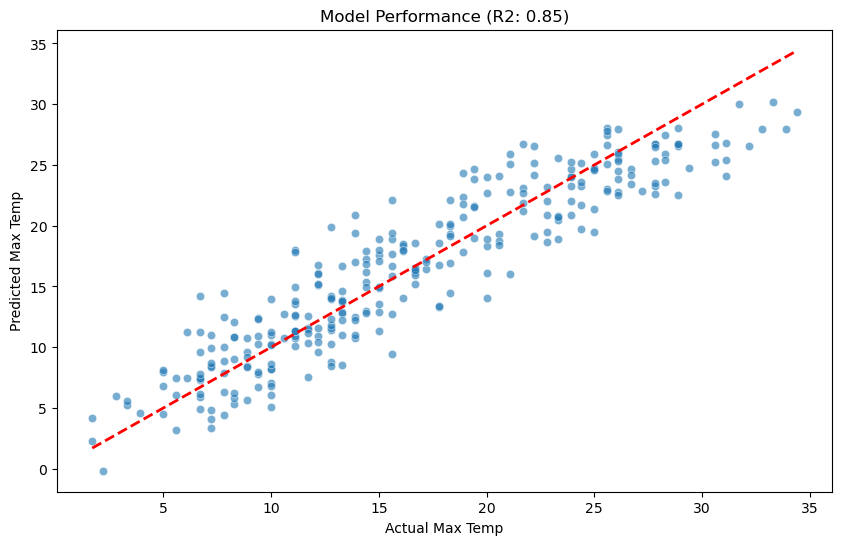

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.6)
# Draw the "Perfect Prediction" line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title(f'Model Performance (R2: {r2_score(y_test, predictions):.2f})')
plt.xlabel('Actual Max Temp')
plt.ylabel('Predicted Max Temp')
plt.show()

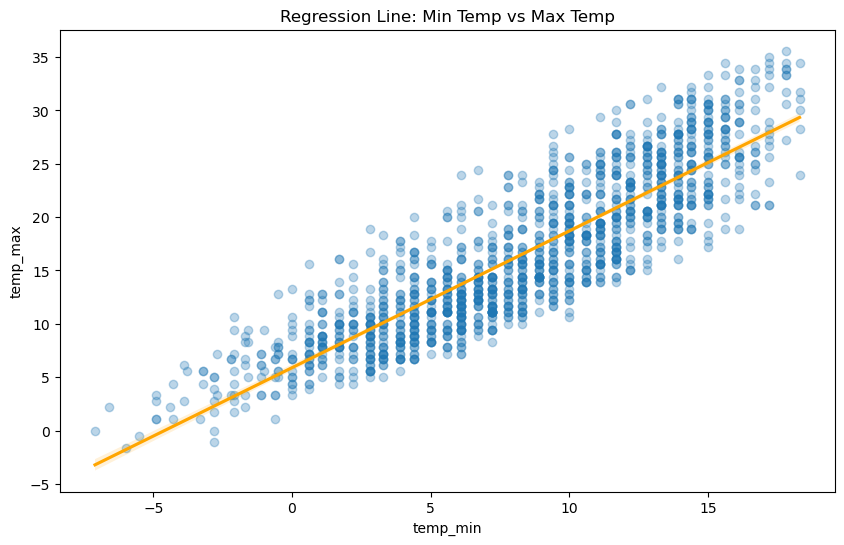

In [13]:
plt.figure(figsize=(10, 6))
sns.regplot(x='temp_min', y='temp_max', data=df, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'orange'})
plt.title('Regression Line: Min Temp vs Max Temp')
plt.show()

In [14]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"--- Model Metrics ---")
print(f"R-Squared (Accuracy Score): {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f} degrees")

--- Model Metrics ---
R-Squared (Accuracy Score): 0.8548
Mean Absolute Error: 2.33 degrees
